In [106]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython import display
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import numpy as np
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

# 1

In [107]:
y = np.array([0] * 240 + [1] * 60)

print(np.unique(y, return_counts=True))
p0 = np.sum(y == 0) / len(y)
p1 = np.sum(y == 1) / len(y)

print(f"p0: {p0}, p1: {p1}")

gini = 1 - (p0 ** 2 + p1 ** 2)  # ehtemale entekhabe eshtebah
print(gini)

entropy = -(p0 * np.log2(p0) + p1 * np.log2(p1))  # mizane bi nazmi
print(entropy)

(array([0, 1]), array([240,  60]))
p0: 0.8, p1: 0.2
0.31999999999999984
0.7219280948873623


In [108]:
import numpy as np

X = np.array(
    [25] * 190 +
    [55] * 110
)

y = np.array(
    [0] * 180 +
    [1] * 10 +
    [0] * 60 +
    [1] * 50
)


def gini(y):
    _, counts = np.unique(y, return_counts=True)
    p = counts / len(y)

    return 1 - np.sum(p ** 2)


def entropy(y):
    _, counts = np.unique(y, return_counts=True)
    p = counts / len(y)

    return -np.sum(p * np.log2(p))


# Split

left = y[X == 25]
right = y[X == 55]

# Gini

gini_parent = gini(y)
gini_left = gini(left)
gini_right = gini(right)

weighted_gini = (
        len(left) / len(y) * gini_left +
        len(right) / len(y) * gini_right
)

# Entropy

entropy_parent = entropy(y)
entropy_left = entropy(left)
entropy_right = entropy(right)

weighted_entropy = (
        len(left) / len(y) * entropy_left +
        len(right) / len(y) * entropy_right
)

# Information Gain

information_gain = entropy_parent - weighted_entropy

print("Parent Gini:", gini_parent)

print("Left Gini:", gini_left)
print("Right Gini:", gini_right)

print("Weighted Gini:", weighted_gini)

print()

print("Parent Entropy:", entropy_parent)
print("Left Entropy:", entropy_left)
print("Right Entropy:", entropy_right)

print("Information Gain:", information_gain)

Parent Gini: 0.31999999999999984
Left Gini: 0.09972299168975085
Right Gini: 0.49586776859504145
Weighted Gini: 0.24497607655502407

Parent Entropy: 0.7219280948873623
Left Entropy: 0.2974722489192896
Right Entropy: 0.9940302114769565
Information Gain: 0.16905125969692825


XOR خطی نیست. یعنی نمی‌توان با یک خط مستقیم دو کلاس را از هم جدا کرد. رگرسیون لجستیک یک مرز تصمیم خطی می‌سازد، بنابراین نمی‌تواند XOR را به‌درستی جدا کند. اما Decision Tree با چند شرط پشت‌سرهم مثل X1 و X2 فضا را به قسمت‌های مختلف تقسیم می‌کند و می‌تواند الگوی غیرخطی XOR را یاد بگیرد.

# 3

In [109]:
df = pd.read_csv('titanic.csv')

columns = ['Pclass', 'Sex', 'Age', 'Pclass']
X = df[['Pclass', 'Sex', 'Age', 'Fare']].copy()
y = df['Survived']
X['Age'] = X['Age'].replace(0, np.nan)
X['Age'] = X['Age'].fillna(X['Age'].mean())

X['Sex'] = X['Sex'].replace(0, np.nan)
X = pd.get_dummies(X, columns=['Sex'], drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# scaler = StandardScaler()
# X_train = scaler.fit_transform(X_train)
# X_test = scaler.transform(X_test)

model_dtc = DecisionTreeClassifier(max_depth=4)
model_lr = LogisticRegression(max_iter=1000)
model_dtc.fit(X_train, y_train)
model_lr.fit(X_train, y_train)

print(f"regression score = {model_lr.score(X_test, y_test)}")
print(f"Decision tree score: {model_dtc.score(X_test, y_test)})")

dt_importance = model_dtc.feature_importances_
dt_best = X.columns[np.argmax(dt_importance)]
print("Most important feature (Decision Tree):", dt_best)

lr_importance = np.abs(model_lr.coef_[0])
lr_best = X.columns[np.argmax(lr_importance)]
print("Most important feature (Logistic Regression):", lr_best)

regression score = 0.8085106382978723
Decision tree score: 0.7872340425531915)
Most important feature (Decision Tree): Sex_male
Most important feature (Logistic Regression): Sex_male


# 4

In [114]:
df = pd.read_csv("heart.csv")
X = df[['thal', 'chol', 'age']]
y = df[['target']]
X = X.replace(0, np.nan)
X = X.fillna(X.mean())

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

models = {
    "unlimited": DecisionTreeClassifier(random_state=42),
    "min_samples_leaf=20": DecisionTreeClassifier(min_samples_leaf=20, random_state=42),
    "max_leaf_nodes=8": DecisionTreeClassifier(max_leaf_nodes=8, random_state=42)
}
for max_depth in [1, 3, 5]:
    print(f"max depth:{max_depth}")
    for name, model in models.items():
        model.max_depth = max_depth
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        acc = accuracy_score(y_test, y_pred)
        print(f"{name}: {acc:.4f}")
    print("-" * 50)


max depth:1
unlimited: 0.7033
min_samples_leaf=20: 0.7033
max_leaf_nodes=8: 0.7033
--------------------------------------------------
max depth:3
unlimited: 0.6703
min_samples_leaf=20: 0.6813
max_leaf_nodes=8: 0.6703
--------------------------------------------------
max depth:5
unlimited: 0.6593
min_samples_leaf=20: 0.6813
max_leaf_nodes=8: 0.6593
--------------------------------------------------


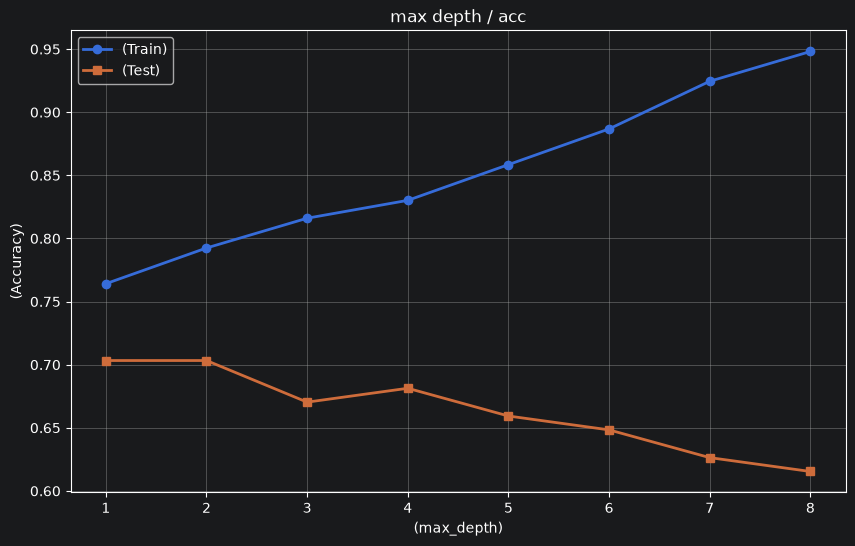

In [117]:
plt.plot(depths, train_scores, marker='o', label='(Train)', linewidth=2)
plt.plot(depths, test_scores, marker='s', label='(Test)', linewidth=2)
plt.xlabel('(max_depth)')
plt.ylabel('(Accuracy)')
plt.title('max depth / acc')
plt.legend()
plt.grid(True)
plt.xticks(depths)
plt.show()